In [1]:
import pandas as pd
import numpy as np
import tpqoa as tpqoa
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.multiclass import OneVsRestClassifier

In [2]:

data = pd.read_csv("D:\\Dissertation Mohit\\Test Environment\\Data\\raw\\EURUSD_2026_01_01_to_2026_02_28.csv", parse_dates=['time'], index_col='time')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3936 entries, 2026-01-01 22:00:00 to 2026-02-27 21:45:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   3936 non-null   float64
dtypes: float64(1)
memory usage: 61.5 KB


In [4]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))
data['direction'] = np.sign(data['returns'])


In [5]:
data

,price,returns,direction
time,,,
2026-01-01 22:00:00,1.17498,NaN,NaN
2026-01-01 22:15:00,1.17495,-0.000026,-1.0
2026-01-01 22:30:00,1.17490,-0.000043,-1.0
2026-01-01 22:45:00,1.17488,-0.000017,-1.0
2026-01-01 23:00:00,1.17466,-0.000187,-1.0
...,...,...,...
2026-02-27 20:45:00,1.18162,-0.000694,-1.0
2026-02-27 21:00:00,1.18142,-0.000169,-1.0
2026-02-27 21:15:00,1.18152,0.000085,1.0


In [6]:
lags = 5
cols = []

for lag in range(1, lags + 1):
    col = f'lag_{lag}'
    data[col] = data['returns'].shift(lag)
    cols.append(col)
data.dropna(inplace=True)


In [7]:
data

,price,returns,direction,lag_1,lag_2,lag_3,lag_4,lag_5
time,,,,,,,,
2026-01-01 23:30:00,1.17496,0.000213,1.0,0.000043,-0.000187,-0.000017,-0.000043,-0.000026
2026-01-01 23:45:00,1.17510,0.000119,1.0,0.000213,0.000043,-0.000187,-0.000017,-0.000043
2026-01-02 00:00:00,1.17528,0.000153,1.0,0.000119,0.000213,0.000043,-0.000187,-0.000017
2026-01-02 00:15:00,1.17517,-0.000094,-1.0,0.000153,0.000119,0.000213,0.000043,-0.000187
2026-01-02 00:30:00,1.17524,0.000060,1.0,-0.000094,0.000153,0.000119,0.000213,0.000043
...,...,...,...,...,...,...,...,...
2026-02-27 20:45:00,1.18162,-0.000694,-1.0,0.000085,0.000051,0.000288,-0.000034,-0.000203
2026-02-27 21:00:00,1.18142,-0.000169,-1.0,-0.000694,0.000085,0.000051,0.000288,-0.000034
2026-02-27 21:15:00,1.18152,0.000085,1.0,-0.000169,-0.000694,0.000085,0.000051,0.000288


In [8]:
mean = data[cols].mean()
std = data[cols].std().replace(0, 1)
data.loc[:, cols] = (data[cols] - mean) / std

In [9]:
mean

lag_1    0.000001
lag_2    0.000001
lag_3    0.000001
lag_4    0.000001
lag_5    0.000002
dtype: float64

In [10]:
lm = OneVsRestClassifier(LogisticRegression(C=1e6, max_iter=100000))

In [11]:
lm.fit(data[cols], data['direction'])

,estimator,LogisticRegre...x_iter=100000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1000000.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [12]:
test = pd.read_csv("D:\\Dissertation Mohit\\Test Environment\\Data\\test\\EURUSD_2026_03_01_to_2026_03_07.csv", parse_dates=['time'], index_col='time')

In [13]:
test

,price
time,
2026-03-01 22:00:00,1.17652
2026-03-01 22:15:00,1.17629
2026-03-01 22:30:00,1.17730
2026-03-01 22:45:00,1.17773
2026-03-01 23:00:00,1.17778
...,...
2026-03-06 20:45:00,1.16060
2026-03-06 21:00:00,1.16169
2026-03-06 21:15:00,1.16161


In [14]:
test['returns'] = np.log(test['price'] / test['price'].shift(1))
test['direction'] = np.sign(test['returns'])
test

,price,returns,direction
time,,,
2026-03-01 22:00:00,1.17652,NaN,NaN
2026-03-01 22:15:00,1.17629,-0.000196,-1.0
2026-03-01 22:30:00,1.17730,0.000858,1.0
2026-03-01 22:45:00,1.17773,0.000365,1.0
2026-03-01 23:00:00,1.17778,0.000042,1.0
...,...,...,...
2026-03-06 20:45:00,1.16060,0.000276,1.0
2026-03-06 21:00:00,1.16169,0.000939,1.0
2026-03-06 21:15:00,1.16161,-0.000069,-1.0


In [15]:
lags = 5
cols = []
for lag in range(1, lags + 1):
    col = f'lag_{lag}'
    test[col] = test['returns'].shift(lag)
    cols.append(col)
test.dropna(inplace=True)

In [16]:
test

,price,returns,direction,lag_1,lag_2,lag_3,lag_4,lag_5
time,,,,,,,,
2026-03-01 23:30:00,1.17664,0.000315,1.0,-0.001283,0.000042,0.000365,0.000858,-0.000196
2026-03-01 23:45:00,1.17592,-0.000612,-1.0,0.000315,-0.001283,0.000042,0.000365,0.000858
2026-03-02 00:00:00,1.17704,0.000952,1.0,-0.000612,0.000315,-0.001283,0.000042,0.000365
2026-03-02 00:15:00,1.17704,0.000000,0.0,0.000952,-0.000612,0.000315,-0.001283,0.000042
2026-03-02 00:30:00,1.17709,0.000042,1.0,0.000000,0.000952,-0.000612,0.000315,-0.001283
...,...,...,...,...,...,...,...,...
2026-03-06 20:45:00,1.16060,0.000276,1.0,0.000353,-0.000577,0.000345,-0.000276,-0.000138
2026-03-06 21:00:00,1.16169,0.000939,1.0,0.000276,0.000353,-0.000577,0.000345,-0.000276
2026-03-06 21:15:00,1.16161,-0.000069,-1.0,0.000939,0.000276,0.000353,-0.000577,0.000345


In [17]:
test[cols] = (test[cols] - mean) / std


In [18]:
test

,price,returns,direction,lag_1,lag_2,lag_3,lag_4,lag_5
time,,,,,,,,
2026-03-01 23:30:00,1.17664,0.000315,1.0,-3.307821,0.105654,0.936959,2.206977,-0.507946
2026-03-01 23:45:00,1.17592,-0.000612,-1.0,0.806408,-3.308040,0.105721,0.936898,2.207439
2026-03-02 00:00:00,1.17704,0.000952,1.0,-1.580132,0.806373,-3.307992,0.105641,0.936842
2026-03-02 00:15:00,1.17704,0.000000,0.0,2.448310,-1.580274,0.806444,-3.308151,0.105246
2026-03-02 00:30:00,1.17709,0.000042,1.0,-0.003622,2.448348,-1.580216,0.806380,-3.309938
...,...,...,...,...,...,...,...,...
2026-03-06 20:45:00,1.16060,0.000276,1.0,0.906653,-1.491116,0.884288,-0.714083,-0.359408
2026-03-06 21:00:00,1.16169,0.000939,1.0,0.706613,0.906622,-1.491058,0.884225,-0.714812
2026-03-06 21:15:00,1.16161,-0.000069,-1.0,2.414148,0.706573,0.906694,-1.491175,0.884148


In [19]:
test['pred'] = lm.predict(test[cols])


In [20]:
test

,price,returns,direction,lag_1,lag_2,lag_3,lag_4,lag_5,pred
time,,,,,,,,,
2026-03-01 23:30:00,1.17664,0.000315,1.0,-3.307821,0.105654,0.936959,2.206977,-0.507946,1.0
2026-03-01 23:45:00,1.17592,-0.000612,-1.0,0.806408,-3.308040,0.105721,0.936898,2.207439,1.0
2026-03-02 00:00:00,1.17704,0.000952,1.0,-1.580132,0.806373,-3.307992,0.105641,0.936842,-1.0
2026-03-02 00:15:00,1.17704,0.000000,0.0,2.448310,-1.580274,0.806444,-3.308151,0.105246,-1.0
2026-03-02 00:30:00,1.17709,0.000042,1.0,-0.003622,2.448348,-1.580216,0.806380,-3.309938,-1.0
...,...,...,...,...,...,...,...,...,...
2026-03-06 20:45:00,1.16060,0.000276,1.0,0.906653,-1.491116,0.884288,-0.714083,-0.359408,1.0
2026-03-06 21:00:00,1.16169,0.000939,1.0,0.706613,0.906622,-1.491058,0.884225,-0.714812,-1.0
2026-03-06 21:15:00,1.16161,-0.000069,-1.0,2.414148,0.706573,0.906694,-1.491175,0.884148,-1.0


In [21]:
hits = np.sign(test['pred'] * test['direction'])
hits.value_counts()

 1.0    240
-1.0    227
 0.0      7
Name: count, dtype: int64

In [22]:
hit_ratio = hits.value_counts()[1] / hits.value_counts().sum()
print(f'Hit Ratio: {hit_ratio:.2%}')

Hit Ratio: 50.63%


In [23]:
test

,price,returns,direction,lag_1,lag_2,lag_3,lag_4,lag_5,pred
time,,,,,,,,,
2026-03-01 23:30:00,1.17664,0.000315,1.0,-3.307821,0.105654,0.936959,2.206977,-0.507946,1.0
2026-03-01 23:45:00,1.17592,-0.000612,-1.0,0.806408,-3.308040,0.105721,0.936898,2.207439,1.0
2026-03-02 00:00:00,1.17704,0.000952,1.0,-1.580132,0.806373,-3.307992,0.105641,0.936842,-1.0
2026-03-02 00:15:00,1.17704,0.000000,0.0,2.448310,-1.580274,0.806444,-3.308151,0.105246,-1.0
2026-03-02 00:30:00,1.17709,0.000042,1.0,-0.003622,2.448348,-1.580216,0.806380,-3.309938,-1.0
...,...,...,...,...,...,...,...,...,...
2026-03-06 20:45:00,1.16060,0.000276,1.0,0.906653,-1.491116,0.884288,-0.714083,-0.359408,1.0
2026-03-06 21:00:00,1.16169,0.000939,1.0,0.706613,0.906622,-1.491058,0.884225,-0.714812,-1.0
2026-03-06 21:15:00,1.16161,-0.000069,-1.0,2.414148,0.706573,0.906694,-1.491175,0.884148,-1.0


In [24]:
test['strategy_returns'] = test['returns'] * test['pred']
test['cumulative_strategy_returns'] = test['strategy_returns'].cumsum().apply(np.exp)
test['cumulative_market_returns'] = test['returns'].cumsum().apply(np.exp)


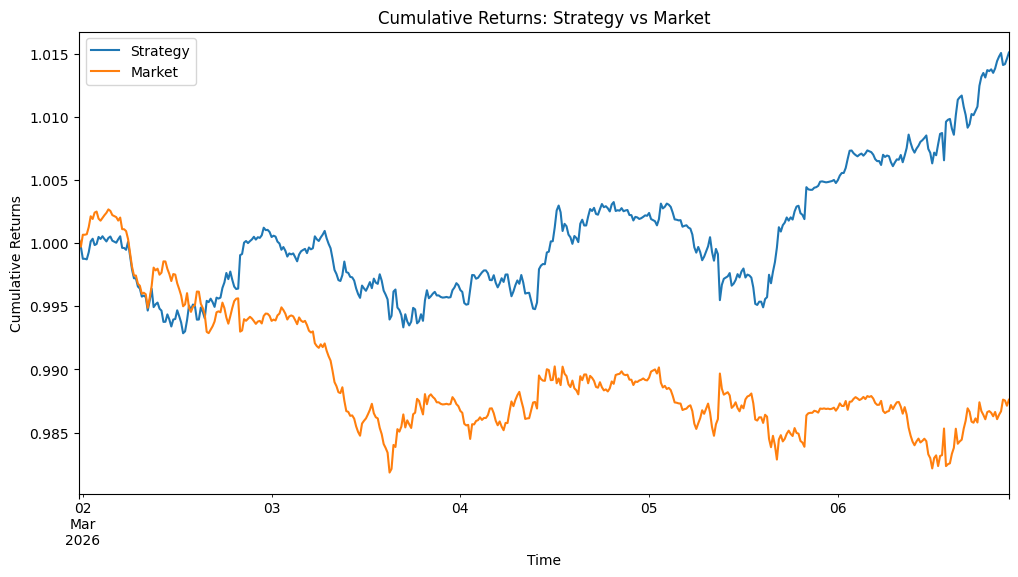

In [25]:
test[['cumulative_strategy_returns', 'cumulative_market_returns']].plot(figsize=(12, 6))
plt.title('Cumulative Returns: Strategy vs Market')
plt.xlabel('Time')
plt.ylabel('Cumulative Returns')
plt.legend(['Strategy', 'Market'])
plt.show()


**MLFLOW Tracking Server & Basics**

In [26]:
import mlflow 
from mlflow.models import infer_signature


In [27]:
mlflow.set_tracking_uri("http://localhost:5000")

In [28]:
# mlflow.set_experiment("Logistic Regression Forex Strategy")

# with mlflow.start_run(run_name="Logistic Regression Test"):
#     mlflow.log_param("model", "Logistic Regression")
#     mlflow.log_param("lags", lags)
#     mlflow.log_param("training_period", data.index.min().strftime('%Y-%m-%d') + " to " + data.index.max().strftime('%Y-%m-%d'))
#     mlflow.log_param("test_period", test.index.min().strftime('%Y-%m-%d') + " to " + test.index.max().strftime('%Y-%m-%d'))
#     mlflow.log_metric("hit_ratio", hit_ratio)
#     mlflow.log_metric("final_strategy_return", test['cumulative_strategy_returns'].iloc[-1])


In [29]:
# mlflow.set_experiment("Logistic Regression Forex Strategy 2 ")

# with mlflow.start_run(run_name="Logistic Regression Test 2"):
#     mlflow.log_param("model", "Logistic Regression")
#     mlflow.log_param("lags", lags)
#     mlflow.log_param("training_period", data.index.min().strftime('%Y-%m-%d') + " to " + data.index.max().strftime('%Y-%m-%d'))
#     mlflow.log_param("test_period", test.index.min().strftime('%Y-%m-%d') + " to " + test.index.max().strftime('%Y-%m-%d'))
#     mlflow.log_metric("hit_ratio", hit_ratio)
#     mlflow.log_metric("final_strategy_return", test['cumulative_strategy_returns'].iloc[-1])

**Final Implementation**

In [30]:
import mlflow 
from mlflow.models import infer_signature

In [31]:
#Set tracking URI to local MLflow server
mlflow.set_tracking_uri("http://localhost:5000")

In [32]:
#Load the dataset
# X,y = data[cols], data['direction']

In [33]:
#Split the dataset into training and testing sets
# split_idx = int(len(X) * 0.8)

X_train, X_test = data[cols], test[cols]
y_train, y_test = data['direction'], test['direction']


In [34]:
#Define Hyperparameters
params = {"penalty":"l2","solver": "lbfgs", "C": 1e6, "max_iter": 100000, "multi_class": "ovr"}

In [35]:
#Train the model
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)

d:\Dissertation Mohit\venv\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1000000.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100000
,multi_class,'ovr'


In [36]:
#Prediction on the test set
y_pred = lr.predict(X_test)
y_pred

array([ 1.,  1., -1., -1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1.,
       -1., -1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,
       -1.,  1.,  1., -1., -1., -1., -1.,  1.,  1.,  1., -1., -1.,  1.,
        1.,  1.,  1.,  1., -1.,  1.,  1., -1., -1., -1., -1.,  1.,  1.,
       -1.,  1.,  1., -1., -1.,  1., -1., -1.,  1., -1., -1.,  1.,  1.,
       -1., -1., -1.,  1., -1.,  1.,  1., -1., -1.,  1., -1., -1.,  1.,
        1., -1., -1.,  1., -1., -1.,  1.,  1.,  1.,  1., -1., -1., -1.,
       -1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1., -1., -1.,  1.,  1.,
       -1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
        1.,  1., -1., -1.,  1.,  1., -1., -1.,  1.,  1., -1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1., -1., -1.,  1., -1., -1., -1., -1.,  1.,
       -1.,  1., -1., -1., -1., -1.,  1.,  1., -1., -1.,  1., -1

In [37]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")

Test Accuracy: 50.63%


In [38]:
#MLFLOW Tracking
mlflow.set_tracking_uri("http://localhost:5000")

#Create or set experiment
mlflow.set_experiment("Logistic Regression Forex Strategy 3")

#Start MLflow run
with mlflow.start_run():
    #log the hyperparameters
    mlflow.log_params(params)
    
    #log metrics
    mlflow.log_metric("accuracy", accuracy)
    
    #Set a tag for the run
    mlflow.set_tag("model_type", "Logistic Regression 2")
    
    #Infer the model signature
    signature = infer_signature(X_train, y_pred)
    
    #Log the model
    mlflow.sklearn.log_model(sk_model=lr,artifact_path= "model", signature=signature,input_example=X_train, registered_model_name="LogisticRegressionForexStrategy2")
    
        

    

2026/03/07 19:38:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/07 19:38:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'LogisticRegressionForexStrategy2' already exists. Creating a new version of this model...
2026/03/07 19:38:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LogisticRegressionForexStrategy2, version 5
Created version '5' of model 'LogisticRegressionForexStrategy2'.


🏃 View run able-bird-755 at: http://localhost:5000/#/experiments/4/runs/c61949095b7a401eb667668e76878b73
🧪 View experiment at: http://localhost:5000/#/experiments/4


In [39]:
#Define Hyperparameters
params = {"penalty":"l1","solver": "liblinear", "max_iter": 1000}


#Train the model
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)



d:\Dissertation Mohit\venv\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [40]:
y_pred = lr.predict(X_test)
y_pred

array([ 1.,  1., -1., -1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1.,
       -1., -1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,
       -1.,  1.,  1., -1., -1., -1., -1.,  1.,  1.,  1., -1., -1.,  1.,
        1.,  1.,  1.,  1., -1.,  1.,  1., -1., -1., -1., -1.,  1.,  1.,
       -1.,  1.,  1., -1., -1.,  1., -1., -1.,  1., -1., -1.,  1.,  1.,
       -1., -1., -1.,  1., -1.,  1.,  1., -1., -1.,  1., -1., -1.,  1.,
        1., -1., -1.,  1., -1., -1.,  1.,  1.,  1.,  1., -1., -1., -1.,
       -1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1., -1., -1.,  1.,  1.,
       -1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
        1.,  1., -1., -1.,  1.,  1., -1., -1.,  1.,  1., -1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1., -1., -1.,  1., -1., -1., -1., -1.,  1.,
       -1.,  1., -1., -1., -1., -1.,  1.,  1., -1., -1.,  1., -1

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")


Test Accuracy: 50.42%


In [42]:
#MLFLOW Tracking
mlflow.set_tracking_uri("http://localhost:5000")

#Create or set experiment
mlflow.set_experiment("Logistic Regression Forex Strategy 3")

#Start MLflow run
with mlflow.start_run():
    #log the hyperparameters
    mlflow.log_params(params)
    
    #log metrics
    mlflow.log_metric("accuracy", accuracy)
    
    #Set a tag for the run
    mlflow.set_tag("model_type", "Logistic Regression 2")
    
    #Infer the model signature
    signature = infer_signature(X_train, y_pred)
    
    #Log the model
    mlflow.sklearn.log_model(sk_model=lr,artifact_path= "model", signature=signature,input_example=X_train, registered_model_name="LogisticRegressionForexStrategy2")
    
        

    

2026/03/07 19:38:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/07 19:38:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'LogisticRegressionForexStrategy2' already exists. Creating a new version of this model...
2026/03/07 19:39:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LogisticRegressionForexStrategy2, version 6


🏃 View run crawling-hog-311 at: http://localhost:5000/#/experiments/4/runs/2d6f8efde09a4024a93aca77f87c44c6
🧪 View experiment at: http://localhost:5000/#/experiments/4


Created version '6' of model 'LogisticRegressionForexStrategy2'.


In [43]:
#Inferencing the model from MLflow registry

import mlflow.sklearn

model_name = "LogisticRegressionForexStrategy2"
model_version = "latest"

model_uri = f"models:/{model_name}/{model_version}"

mlflow.sklearn.load_model(model_uri)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
model_uri 

'models:/LogisticRegressionForexStrategy2/latest'

In [45]:
y_pred_new = lr.predict(X_test)

**RUN HYPERPARAMS TUNING WHILE TRAINING A MODEL**

In [1]:
import os

In [ ]:
os.eniron[' MLFLOW_TRACKING_URI'] = "https://dagshub.com/Mohit-Bhoir/Multimodal-Trihybrid-Algorithmic-Forex-Trading-Model-.mlflow"
os.environ['MLFLOW_TRAKCING_USERNAME'] = "Mohit-Bhoir"
os.environ['MLFLOW_TRACKING_PASSWORD'] = "8407fd9e577fa22b1f5f3df39f7a37252fd1ded3"

*Lets run the model on RandomForestClassifier using GridSearchCV and then compare the results*

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [47]:
from urllib.parse import urlparse

In [50]:
#hyperparameters for Random Forest using GridSearchCV

def hyperparameter_tuning_rf(X_train, y_train,param_grid):
    
    rf = RandomForestClassifier()
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        verbose=2
    )
    grid_search.fit(X_train, y_train)

    print(f"Best Hyperparameters: {grid_search.best_params_}")
    return grid_search

In [51]:
from mlflow.models import infer_signature
infer_signature(X_train, y_train)

#Define the hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],             # Number of trees (more is generally better but slower)
    'max_depth': [None, 5, 10],             # Depth of trees; 'None' lets them grow until pure
    'min_samples_split': [2, 5],            # Minimum samples required to split a node
    'min_samples_leaf': [1, 2]
}

#Start the mlflow experiments

#Create or set experiment
mlflow.set_experiment("Random Forest Forex Strategy")


with mlflow.start_run():
    #Perform hyperparameter tuning
    grid_search = hyperparameter_tuning_rf(X_train, y_train,param_grid)
    
    #Get best model
    best_model = grid_search.best_estimator_
    
    
    #Evaluate the model
    y_pred_rf = best_model.predict(X_test)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    
    #Log best params and metrics 
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("accuracy_rf", accuracy_rf)
    
    #tracking uri 
    mlflow.set_tracking_uri("http://localhost:5000")
    tracking_url_type_store = urlparse(mlflow.get_tracking_uri()).scheme
    
    if tracking_url_type_store != "file":
        mlflow.sklearn.log_model(best_model, "model_rf", registered_model_name="RandomForestForexStrategy")
    else:
        mlflow.sklearn.log_model(best_model, "model_rf",signature=infer_signature(X_train, y_train))
    
    print(f"Best Hyperparameters: {grid_search.best_params_}")    
    print(f"Random Forest Test Accuracy: {accuracy_rf:.2%}")
    

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


2026/03/07 19:39:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/07 19:39:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'RandomForestForexStrategy'.
2026/03/07 19:40:01 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RandomForestForexStrategy, version 1
Created version '1' of model 'RandomForestForexStrategy'.


Best Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Test Accuracy: 51.27%
🏃 View run flawless-sow-678 at: http://localhost:5000/#/experiments/5/runs/b6a8f8256f564ad9ae0b88f97de85ba7
🧪 View experiment at: http://localhost:5000/#/experiments/5
